In [1]:
import sys
import os

sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


In [2]:
X1 = pd.read_csv("mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("mod_data/y3.1", index_col="QSPRID")


In [3]:
y1.sum()/y1.count()

Y    0.583248
dtype: float64

In [4]:

display(X1)

,300,301,302,303,304,305,306,307,308,309,...,RDkit_fr_sulfide,RDkit_fr_sulfonamd,RDkit_fr_sulfone,RDkit_fr_term_acetylene,RDkit_fr_tetrazole,RDkit_fr_thiazole,RDkit_fr_thiophene,RDkit_fr_unbrch_alkane,RDkit_fr_urea,RDkit_qed
QSPRID,,,,,,,,,,,,,,,,,,,,,
A2ARDataset_0000,-0.451604,0.508020,-0.215841,0.279434,-0.177561,-0.714216,0.962861,0.353974,0.372018,0.283712,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.442464
A2ARDataset_0001,-0.580816,0.661863,-0.196615,0.414776,-0.178242,-0.572745,0.862649,0.331915,0.451654,0.373833,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.442464
A2ARDataset_0002,-0.149355,0.020688,-0.017025,0.351651,-0.464647,-0.758257,0.899988,0.121955,0.597253,0.313429,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.335977
A2ARDataset_0003,-0.221894,0.101965,0.058321,0.376781,-0.432157,-0.659786,0.939272,0.103234,0.660293,0.480575,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.374079
A2ARDataset_0004,-0.497377,0.512645,0.018194,0.279497,-0.382501,-0.760101,0.666209,0.327176,0.513706,0.454725,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.371188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2ARDataset_7851,-0.662869,0.594725,0.420540,0.181816,0.006698,-0.819028,0.484375,0.166745,0.425275,0.149207,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.384736
A2ARDataset_7852,0.208791,0.713855,0.259613,0.296591,-0.001371,-0.784151,0.559925,0.239590,0.084138,0.329249,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.450544
A2ARDataset_7853,-0.144258,0.504814,0.374749,0.618364,-0.061048,-0.881780,0.464672,0.045130,0.103850,0.169520,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.477657


In [5]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [6]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=1, random_state=42)
X1, y1 = smote.fit_resample(X1, y1)
display(pd.DataFrame(X1))

,0,1,2,3,4,5,6,7,8,9,...,4668,4669,4670,4671,4672,4673,4674,4675,4676,4677
0,-0.368807,0.449969,-2.179742,0.533317,-0.305330,0.565028,1.694528,0.698365,-0.127115,0.181530,...,-0.223891,-0.279947,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,-0.558479
1,-0.833699,0.984010,-2.094093,1.115777,-0.308247,1.050824,1.285909,0.619204,0.147659,0.597666,...,-0.223891,-0.279947,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,-0.558479
2,0.718652,-1.241727,-1.294048,0.844113,-1.534152,0.413797,1.438163,-0.134257,0.650031,0.318751,...,-0.223891,-0.279947,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,-1.138625
3,0.457665,-0.959587,-0.958390,0.952259,-1.395083,0.751934,1.598343,-0.201440,0.867544,1.090554,...,-0.223891,-0.279947,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,-0.931042
4,-0.533496,0.466023,-1.137150,0.533591,-1.182542,0.407465,0.484916,0.602196,0.361761,0.971192,...,-0.223891,-0.279947,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,-0.946793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9159,-1.372795,-0.408414,-0.269412,-0.296725,0.278256,-0.185780,-0.313672,-0.001844,0.525074,-0.587704,...,-0.223891,1.061998,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,0.403723
9160,-0.358796,-1.813513,-0.777799,-0.521747,0.828404,-0.579002,0.031730,1.028444,1.603450,-0.841053,...,-0.223891,-0.279947,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,-0.608933
9161,-0.535688,1.280876,-0.035218,-0.665111,-1.151365,0.063225,-0.018170,-0.169370,0.120780,-0.797153,...,-0.223891,-0.279947,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,0.137063
9162,0.350739,0.666471,2.062234,-0.074140,1.242787,1.830375,-0.051098,-0.894747,-0.933312,-0.810303,...,-0.223891,3.422514,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,3.659017,1.138819


In [7]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit(X1)
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1
from sklearn.decomposition import PCA
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

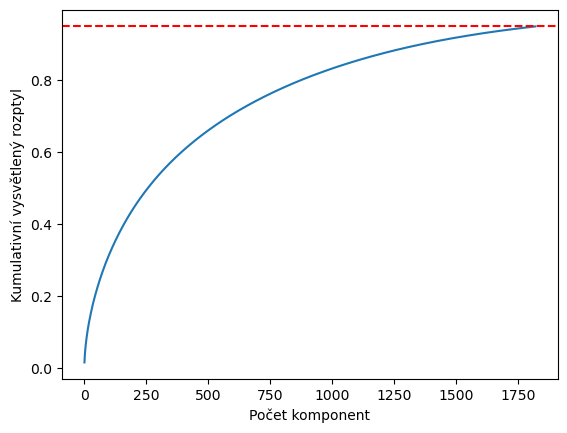

In [8]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X1, y1)

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=8)

In [10]:
pred = knn.predict(X2)

In [11]:
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score

print("Acc:", accuracy_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.6224066390041494
Mcc: 0.31646186238344215


In [12]:
from sklearn.model_selection import ParameterGrid
from tqdm import tqdm
import pandas as pd
param_grid = ParameterGrid({
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15, 21, 31],  # různé hodnoty K
    'weights': ['uniform', 'distance'],             # vážení sousedů
    'metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski'],  # různé metriky vzdálenosti
    'p': [1, 2],                                     # pro minkowski: p=1 (Manhattan), p=2 (Eukleidovská)
    'leaf_size': [10, 20, 30, 50, 100],              # ovlivňuje rychlost vyhledávání
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']  # různé algoritmy pro hledání sousedů
})

val_mcc = []
val_f1 = []
val_acc = []
for param in tqdm(param_grid, total=len(param_grid)):
    knn = KNeighborsClassifier(**param)
    knn.fit(X1, y1["Y"])
    pred = knn.predict(X2)
    val_mcc.append(matthews_corrcoef(pred, y2["Y"]))
    val_f1.append(f1_score(pred, y2["Y"]))
    val_acc.append(accuracy_score(pred, y2["Y"]))
    print("Params:", param, "\nMCC:", matthews_corrcoef(pred, y2["Y"]))



  0%|                                            | 1/2880 [00:02<2:13:03,  2.77s/it]

Params: {'algorithm': 'auto', 'leaf_size': 10, 'metric': 'euclidean', 'n_neighbors': 1, 'p': 1, 'weights': 'uniform'} 
MCC: 0.2967970168359558


  0%|                                            | 2/2880 [00:05<2:09:51,  2.71s/it]

Params: {'algorithm': 'auto', 'leaf_size': 10, 'metric': 'euclidean', 'n_neighbors': 1, 'p': 1, 'weights': 'distance'} 
MCC: 0.2967970168359558


  0%|                                            | 3/2880 [00:08<2:07:32,  2.66s/it]

...

Params: {'algorithm': 'brute', 'leaf_size': 100, 'metric': 'minkowski', 'n_neighbors': 31, 'p': 1, 'weights': 'distance'} 
MCC: 0.22819252257873363


100%|███████████████████████████████████████▉| 2879/2880 [27:43:16<00:05,  5.44s/it]

Params: {'algorithm': 'brute', 'leaf_size': 100, 'metric': 'minkowski', 'n_neighbors': 31, 'p': 2, 'weights': 'uniform'} 
MCC: 0.23343619710730348


100%|████████████████████████████████████████| 2880/2880 [27:43:19<00:00, 34.65s/it]

Params: {'algorithm': 'brute', 'leaf_size': 100, 'metric': 'minkowski', 'n_neighbors': 31, 'p': 2, 'weights': 'distance'} 
MCC: 0.2486191683932606


In [28]:
knn_res = pd.DataFrame(param_grid)

In [29]:
knn_res["mcc"] = val_mcc
knn_res["f1"] = val_f1
knn_res["acc"] = val_acc

In [31]:
knn_res.sort_values(by=["mcc", "f1", "acc"], ascending=False, inplace=True)

In [33]:
knn_res.to_csv("res/knn_res_val_1.1.csv")

In [32]:
knn_res

,algorithm,leaf_size,metric,n_neighbors,p,weights,mcc,f1,acc
93,auto,10,chebyshev,11,1,distance,0.356620,0.729126,0.686243
95,auto,10,chebyshev,11,2,distance,0.356620,0.729126,0.686243
237,auto,20,chebyshev,11,1,distance,0.356620,0.729126,0.686243
239,auto,20,chebyshev,11,2,distance,0.356620,0.729126,0.686243
381,auto,30,chebyshev,11,1,distance,0.356620,0.729126,0.686243
...,...,...,...,...,...,...,...,...,...
2662,brute,50,manhattan,31,2,uniform,0.216596,0.423445,0.538462
2732,brute,50,minkowski,31,1,uniform,0.216596,0.423445,0.538462
2804,brute,100,manhattan,31,1,uniform,0.216596,0.423445,0.538462
2806,brute,100,manhattan,31,2,uniform,0.216596,0.423445,0.538462


In [18]:
import numpy as np
best_params = param_grid[np.argmax(val_mcc)]

In [19]:
best_params

{'weights': 'distance',
 'p': 1,
 'n_neighbors': 11,
 'metric': 'chebyshev',
 'leaf_size': 10,
 'algorithm': 'auto'}

In [20]:
knn = KNeighborsClassifier(**best_params)
knn.fit(X1, y1)

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(leaf_size=10, metric='chebyshev', n_neighbors=11, p=1,
                     weights='distance')

In [21]:
pred = knn.predict(X2)

print("Acc:", accuracy_score(pred, y2))
print("F1:", f1_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.6862432173635493
F1: 0.7291264811242767
Mcc: 0.356620053816026


In [22]:
pred_test = knn.predict(X3)

print("Acc:", accuracy_score(pred_test, y3))
print("F1:", f1_score(pred_test, y3))
print("Mcc:", matthews_corrcoef(pred_test, y3))

Acc: 0.6642664266426642
F1: 0.7306859205776173
Mcc: 0.2850752429524454
